# Baseline Article Replication — Final Clean Implementation

This notebook is the **clean, executable, GitHub-ready implementation** of the baseline article replication used in the thesis.

## Main pipeline

1. Configuration and reproducibility
2. Dataset loading and sanity checks
3. Paper-aligned percentile capping
4. Eta correlation-ratio screening report
5. One-hot + scaling diagnostic representation
6. True FAMD on the mixed-data table
7. Baseline KMeans and Agglomerative clustering
8. Internal validation metrics
9. Elbow and dendrogram diagnostics
10. Cluster profiling
11. FAMD dimensionality sensitivity analysis
12. Final run summary and exported-file manifest

## Important cleanup decisions

- The dataset-path problem from the previous notebook is fixed.
- The notebook first uses the exact local dataset path used for this project:
  `C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv`
- For GitHub portability, the notebook also supports an environment variable and a repository-local `data/` folder as fallbacks.
- Duplicate FAMD correction blocks were consolidated into one implementation.
- One-hot encoding is retained only as a diagnostic/reporting representation; **FAMD receives the mixed numerical/categorical table directly**.
- The FAMD variance/inertia report avoids silently renormalizing a truncated set of components to 100%.
- The sensitivity-analysis block does not overwrite the main 3-component baseline result.

## Block 0 — Imports, paths, reproducibility, and experiment configuration

This block contains the settings that a user may reasonably change.

The dataset path is resolved in the following order:

1. the exact local thesis path, if it exists;
2. `BASELINE_DATASET_PATH`, if defined;
3. `./data/Shopping_Trends_And_Customer_Behaviour_Dataset.csv`.

This makes the notebook work on the current project computer while remaining usable on GitHub.

In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import sys
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------------------
# Project and dataset paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()

LOCAL_DATASET_PATH = Path(
    r"C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv"
)

PORTABLE_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "Shopping_Trends_And_Customer_Behaviour_Dataset.csv"
)

ENV_DATASET_PATH = os.environ.get("BASELINE_DATASET_PATH")

if LOCAL_DATASET_PATH.exists():
    DATASET_PATH = LOCAL_DATASET_PATH
    DATASET_PATH_SOURCE = "local thesis path"
elif ENV_DATASET_PATH:
    DATASET_PATH = Path(ENV_DATASET_PATH).expanduser()
    DATASET_PATH_SOURCE = "BASELINE_DATASET_PATH environment variable"
elif PORTABLE_DATASET_PATH.exists():
    DATASET_PATH = PORTABLE_DATASET_PATH
    DATASET_PATH_SOURCE = "repository data folder"
else:
    # Keep the local thesis path in the error message because this is the
    # primary path for the current project computer.
    DATASET_PATH = LOCAL_DATASET_PATH
    DATASET_PATH_SOURCE = "local thesis path (not found)"

# ---------------------------------------------------------------------
# Output directory
# ---------------------------------------------------------------------
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "baseline_replication"
    / RUN_ID
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Baseline-replication configuration
# ---------------------------------------------------------------------
EXPECTED_ROWS = 3900

ETA_THRESHOLD = 0.03

CAP_LOWER_Q = 0.05
CAP_UPPER_Q = 0.95

N_COMPONENTS_FAMD = 3
MAX_FAMD_REPORT_COMPONENTS = 20

K_CANDIDATES = [3, 4]
ELBOW_K_RANGE = list(range(2, 11))

RANDOM_STATE = 42

PROFILE_LABEL_KEY = "agglo_ward_k4"

RUN_FAMD_SENSITIVITY = True
SENSITIVITY_COMPONENTS = [3, 5, 8, 10, 12, 15, 20]
SENSITIVITY_K_VALUES = [3, 4]

SAVE_FIGURES = True
FIG_DPI = 220

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CONFIG = {
    "dataset_path": str(DATASET_PATH),
    "dataset_path_source": DATASET_PATH_SOURCE,
    "expected_rows": EXPECTED_ROWS,
    "eta_threshold": ETA_THRESHOLD,
    "cap_lower_q": CAP_LOWER_Q,
    "cap_upper_q": CAP_UPPER_Q,
    "n_components_famd": N_COMPONENTS_FAMD,
    "max_famd_report_components": MAX_FAMD_REPORT_COMPONENTS,
    "k_candidates": K_CANDIDATES,
    "elbow_k_range": ELBOW_K_RANGE,
    "random_state": RANDOM_STATE,
    "profile_label_key": PROFILE_LABEL_KEY,
    "run_famd_sensitivity": RUN_FAMD_SENSITIVITY,
    "sensitivity_components": SENSITIVITY_COMPONENTS,
    "sensitivity_k_values": SENSITIVITY_K_VALUES,
    "run_id": RUN_ID,
    "out_dir": str(OUT_DIR),
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
}

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

print("Baseline article replication configuration")
print("=" * 70)
print("Dataset path source:", DATASET_PATH_SOURCE)
print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())
print("Output directory:", OUT_DIR.resolve())
print("=" * 70)

display(pd.DataFrame(CONFIG.items(), columns=["Parameter", "Value"]))

Baseline article replication configuration
Dataset path source: local thesis path
Dataset path: C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv
Dataset exists: True
Output directory: C:\Users\Sina\Desktop\دفاع\GITHUB\THE IMPLEMENTATION OF BASELINE ARTICLE\outputs\baseline_replication\20260921_143943


,Parameter,Value
0,dataset_path,C:\Users\Sina\Desktop\Thesis\Shopping_Trends_A...
1,dataset_path_source,local thesis path
2,expected_rows,3900
3,eta_threshold,0.03
4,cap_lower_q,0.05
5,cap_upper_q,0.95
6,n_components_famd,3
7,max_famd_report_components,20
8,k_candidates,"[3, 4]"
9,elbow_k_range,"[2, 3, 4, 5, 6, 7, 8, 9, 10]"


## Block 1 — Shared utility functions

These helpers reduce duplication and keep later cells focused on the methodology.
They do not change the analytical logic.

In [2]:
def save_dataframe(df: pd.DataFrame, filename: str) -> Path:
    """Save a DataFrame into the current run directory."""
    path = OUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8")
    return path


def save_json(payload: dict[str, Any], filename: str) -> Path:
    """Save a JSON-serializable dictionary into the current run directory."""
    path = OUT_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    return path


def finalize_figure(filename: str | None = None) -> None:
    """Tighten, optionally save, display, and close the active figure."""
    plt.tight_layout()

    if SAVE_FIGURES and filename:
        plt.savefig(
            OUT_DIR / filename,
            dpi=FIG_DPI,
            bbox_inches="tight",
        )

    plt.show()
    plt.close()


def describe_numeric(series: pd.Series) -> dict[str, float | int]:
    """Return compact descriptive statistics for a numeric Series."""
    s = pd.to_numeric(series, errors="coerce").astype(float)
    arr = s.to_numpy()
    valid = arr[np.isfinite(arr)]

    if valid.size == 0:
        return {
            "min": np.nan,
            "p05": np.nan,
            "p25": np.nan,
            "median": np.nan,
            "p75": np.nan,
            "p95": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "std": np.nan,
            "n": 0,
        }

    return {
        "min": float(np.min(valid)),
        "p05": float(np.percentile(valid, 5)),
        "p25": float(np.percentile(valid, 25)),
        "median": float(np.percentile(valid, 50)),
        "p75": float(np.percentile(valid, 75)),
        "p95": float(np.percentile(valid, 95)),
        "max": float(np.max(valid)),
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "n": int(valid.size),
    }


def eta_correlation_ratio(
    categories: pd.Series,
    measurements: pd.Series,
) -> float:
    """
    Compute the Eta correlation ratio between a categorical variable
    and a continuous variable.
    """
    y = pd.to_numeric(measurements, errors="coerce")
    valid = y.notna()

    y = y.loc[valid]
    x = (
        categories.loc[valid]
        .astype("string")
        .fillna("MISSING")
    )

    if y.empty:
        return np.nan

    grand_mean = float(y.mean())
    denominator = float(((y - grand_mean) ** 2).sum())

    if denominator <= 0:
        return np.nan

    numerator = 0.0

    for category in x.unique():
        values = y.loc[x == category]

        if len(values) > 0:
            numerator += (
                len(values)
                * float((values.mean() - grand_mean) ** 2)
            )

    return float(np.sqrt(numerator / denominator))


def cluster_metrics(
    X: np.ndarray,
    labels: np.ndarray,
) -> dict[str, float]:
    """
    Compute the three internal clustering metrics used in the thesis:
    Silhouette, Davies-Bouldin, and Calinski-Harabasz.
    """
    from sklearn.metrics import (
        calinski_harabasz_score,
        davies_bouldin_score,
        silhouette_score,
    )

    y = np.asarray(labels)
    n_clusters = len(np.unique(y))

    if n_clusters < 2 or n_clusters >= len(y):
        return {
            "Silhouette": np.nan,
            "DBI": np.nan,
            "CHI": np.nan,
        }

    return {
        "Silhouette": float(silhouette_score(X, y)),
        "DBI": float(davies_bouldin_score(X, y)),
        "CHI": float(calinski_harabasz_score(X, y)),
    }


def extract_famd_variance(
    model,
) -> tuple[pd.DataFrame, str, str]:
    """
    Extract FAMD variance/inertia information across prince versions.

    The function prefers Prince's own percentage/inertia attributes.
    It avoids presenting a truncated subset of components as if it
    necessarily represented 100% of total inertia.
    """
    # -------------------------------------------------------------
    # 1) Direct percentage-of-variance attributes
    # -------------------------------------------------------------
    for attr in [
        "percentage_of_variance_",
        "percentage_of_variance",
    ]:
        if hasattr(model, attr):
            values = np.asarray(
                getattr(model, attr),
                dtype=float,
            ).ravel()

            values = values[np.isfinite(values)]

            if values.size > 0 and values.sum() > 0:
                # Some versions use [0, 1], others percentage units.
                if values.sum() <= 1.000001:
                    percentages = values * 100.0
                    interpretation = (
                        "Prince percentage-of-variance proportions "
                        "converted to percent"
                    )
                else:
                    percentages = values.copy()
                    interpretation = (
                        "Prince percentage-of-variance values"
                    )

                table = pd.DataFrame({
                    "Component_Number": np.arange(
                        1, len(values) + 1
                    ),
                    "Component": [
                        f"Comp{i}"
                        for i in range(1, len(values) + 1)
                    ],
                    "Prince_Raw_Value": values,
                    "Reported_Explained_Percent": percentages,
                    "Reported_Cumulative_Percent": np.cumsum(
                        percentages
                    ),
                })

                return table, attr, interpretation

    # -------------------------------------------------------------
    # 2) Explained-inertia attributes
    # -------------------------------------------------------------
    for attr in [
        "explained_inertia_",
        "explained_inertia",
    ]:
        if hasattr(model, attr):
            values = np.asarray(
                getattr(model, attr),
                dtype=float,
            ).ravel()

            values = values[np.isfinite(values)]

            if values.size > 0 and values.sum() > 0:
                if values.sum() <= 1.000001:
                    percentages = values * 100.0
                    interpretation = (
                        "Prince explained-inertia proportions "
                        "converted to percent"
                    )
                else:
                    percentages = values.copy()
                    interpretation = (
                        "Prince explained-inertia values"
                    )

                table = pd.DataFrame({
                    "Component_Number": np.arange(
                        1, len(values) + 1
                    ),
                    "Component": [
                        f"Comp{i}"
                        for i in range(1, len(values) + 1)
                    ],
                    "Prince_Raw_Value": values,
                    "Reported_Explained_Percent": percentages,
                    "Reported_Cumulative_Percent": np.cumsum(
                        percentages
                    ),
                })

                return table, attr, interpretation

    # -------------------------------------------------------------
    # 3) Eigenvalue fallback
    # -------------------------------------------------------------
    for attr in ["eigenvalues_", "eigenvalues"]:
        if hasattr(model, attr):
            eigenvalues = np.asarray(
                getattr(model, attr),
                dtype=float,
            ).ravel()

            eigenvalues = eigenvalues[
                np.isfinite(eigenvalues)
            ]

            if eigenvalues.size == 0 or eigenvalues.sum() <= 0:
                continue

            total_inertia = getattr(
                model,
                "total_inertia_",
                None,
            )

            if total_inertia is None:
                total_inertia = getattr(
                    model,
                    "total_inertia",
                    None,
                )

            if (
                total_inertia is not None
                and np.isfinite(total_inertia)
                and float(total_inertia) > 0
            ):
                percentages = (
                    eigenvalues
                    / float(total_inertia)
                    * 100.0
                )
                interpretation = (
                    "Eigenvalues divided by Prince total inertia"
                )
            else:
                # This is explicitly labeled as a relative share of
                # the extracted eigenvalues only.
                percentages = (
                    eigenvalues
                    / eigenvalues.sum()
                    * 100.0
                )
                interpretation = (
                    "Relative share among extracted eigenvalues only; "
                    "not guaranteed to be global FAMD inertia"
                )

            table = pd.DataFrame({
                "Component_Number": np.arange(
                    1, len(eigenvalues) + 1
                ),
                "Component": [
                    f"Comp{i}"
                    for i in range(1, len(eigenvalues) + 1)
                ],
                "Prince_Raw_Value": eigenvalues,
                "Reported_Explained_Percent": percentages,
                "Reported_Cumulative_Percent": np.cumsum(
                    percentages
                ),
            })

            return table, attr, interpretation

    related_attributes = [
        attr
        for attr in dir(model)
        if any(
            token in attr.lower()
            for token in (
                "variance",
                "inertia",
                "eigen",
            )
        )
    ]

    raise RuntimeError(
        "Could not extract FAMD variance/inertia information. "
        f"Related Prince attributes: {related_attributes}"
    )

## Block 2 — Load dataset and perform sanity checks

This block:

- verifies the selected dataset path;
- loads the CSV;
- removes accidental `Unnamed` index columns;
- normalizes common missing-value text tokens;
- explicitly converts the main numerical variables;
- checks duplicate rows and duplicate customer IDs;
- exports the dataset schema and a sanity-check report.

In [3]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found.\n\n"
        f"Selected path: {DATASET_PATH}\n"
        f"Resolved path: {DATASET_PATH.resolve()}\n"
        f"Path source: {DATASET_PATH_SOURCE}\n\n"
        "For the current project computer, the expected file is:\n"
        r"C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv"
        "\n\nFor another computer, either:\n"
        "1. place the CSV inside ./data/, or\n"
        "2. set BASELINE_DATASET_PATH to the full CSV path."
    )

df = pd.read_csv(
    DATASET_PATH,
    low_memory=False,
)

df.columns = [
    str(column).strip()
    for column in df.columns
]

# -------------------------------------------------------------
# Remove accidental CSV index columns
# -------------------------------------------------------------
unnamed_columns = [
    column
    for column in df.columns
    if column.lower().startswith("unnamed")
]

if unnamed_columns:
    df = df.drop(columns=unnamed_columns)

# -------------------------------------------------------------
# Normalize common missing-value tokens
# -------------------------------------------------------------
MISSING_TOKENS = {
    "",
    "na",
    "n/a",
    "none",
    "null",
    "nan",
    "-",
    "?",
}

object_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

for column in object_columns:
    series = (
        df[column]
        .astype("string")
        .str.strip()
    )

    df[column] = series.mask(
        series.str.lower().isin(MISSING_TOKENS),
        other=pd.NA,
    )

# -------------------------------------------------------------
# Explicitly coerce the core numerical variables
# -------------------------------------------------------------
NUMERIC_CORE = [
    column
    for column in [
        "Age",
        "Purchase Amount (USD)",
        "Review Rating",
        "Previous Purchases",
    ]
    if column in df.columns
]

coercion_rows = []

for column in NUMERIC_CORE:
    missing_before = int(
        df[column].isna().sum()
    )

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

    missing_after = int(
        df[column].isna().sum()
    )

    coercion_rows.append({
        "Feature": column,
        "Missing_Before_Coercion": missing_before,
        "Missing_After_Coercion": missing_after,
    })

# -------------------------------------------------------------
# Sanity checks
# -------------------------------------------------------------
duplicate_rows = int(
    df.duplicated().sum()
)

duplicate_customer_ids = (
    int(
        df["Customer ID"]
        .duplicated()
        .sum()
    )
    if "Customer ID" in df.columns
    else None
)

numeric_columns_loaded = (
    df.select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

categorical_columns_loaded = [
    column
    for column in df.columns
    if column not in numeric_columns_loaded
]

schema_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": [
        str(df[column].dtype)
        for column in df.columns
    ],
    "Missing": [
        int(df[column].isna().sum())
        for column in df.columns
    ],
    "Unique_Values": [
        int(
            df[column]
            .nunique(dropna=False)
        )
        for column in df.columns
    ],
})

print("Dataset loaded successfully")
print("=" * 70)
print("Path:", DATASET_PATH)
print("Shape:", df.shape)

if len(df) == EXPECTED_ROWS:
    print(
        f"Row-count check: matched expected n={EXPECTED_ROWS}"
    )
else:
    print(
        f"WARNING: expected {EXPECTED_ROWS} rows, "
        f"but loaded {len(df)} rows"
    )

print(
    "Missing values after normalization:",
    int(df.isna().sum().sum()),
)
print("Duplicate rows:", duplicate_rows)
print(
    "Duplicate Customer IDs:",
    duplicate_customer_ids,
)

print("\nNumeric coercion report")
display(
    pd.DataFrame(coercion_rows)
)

print("\nDataset schema")
display(schema_df)

save_dataframe(
    schema_df,
    "block02_schema.csv",
)

save_json(
    {
        "dataset_path": str(DATASET_PATH),
        "shape": [
            int(df.shape[0]),
            int(df.shape[1]),
        ],
        "duplicate_rows": duplicate_rows,
        "duplicate_customer_ids": duplicate_customer_ids,
        "missing_total": int(
            df.isna().sum().sum()
        ),
        "numeric_columns": numeric_columns_loaded,
        "categorical_columns": categorical_columns_loaded,
    },
    "block02_sanity.json",
)

Dataset loaded successfully
Path: C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv
Shape: (3900, 17)
Row-count check: matched expected n=3900
Missing values after normalization: 0
Duplicate rows: 0
Duplicate Customer IDs: 0

Numeric coercion report


,Feature,Missing_Before_Coercion,Missing_After_Coercion
0,Age,0,0
1,Purchase Amount (USD),0,0
2,Review Rating,0,0
3,Previous Purchases,0,0



Dataset schema


,Column,Dtype,Missing,Unique_Values
0,Customer ID,int64,0,3900
1,Age,int64,0,53
2,Gender,string,0,2
3,Item Purchased,string,0,25
4,Category,string,0,4
5,Purchase Amount (USD),int64,0,81
6,Location,string,0,50
7,Color,string,0,25
8,Season,string,0,4
9,Review Rating,float64,0,26


WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block02_sanity.json')

## Block 3 — Paper-aligned percentile capping

The supplied baseline implementation caps only:

- `Purchase Amount (USD)`
- `Previous Purchases`

using the 5th and 95th percentiles.

`Age` and `Review Rating` are intentionally not capped in this replication.

In [4]:
df_original = df.copy(deep=True)
df_capped = df.copy(deep=True)

CAP_COLUMNS = [
    column
    for column in [
        "Purchase Amount (USD)",
        "Previous Purchases",
    ]
    if column in df_capped.columns
]

if not CAP_COLUMNS:
    raise ValueError(
        "The expected percentile-capping columns "
        "were not found in the dataset."
    )

capping_rows = []

for column in CAP_COLUMNS:
    series = pd.to_numeric(
        df_capped[column],
        errors="coerce",
    ).astype(float)

    before = describe_numeric(series)

    lower_bound = float(
        series.quantile(CAP_LOWER_Q)
    )

    upper_bound = float(
        series.quantile(CAP_UPPER_Q)
    )

    capped_series = series.clip(
        lower=lower_bound,
        upper=upper_bound,
    )

    changed_values = int(
        (
            (capped_series != series)
            & series.notna()
        ).sum()
    )

    df_capped[column] = capped_series

    after = describe_numeric(
        capped_series
    )

    capping_rows.append({
        "Feature": column,
        "Cap_Low": lower_bound,
        "Cap_High": upper_bound,
        "Changed_Values": changed_values,
        "Changed_Percent": (
            100.0
            * changed_values
            / max(1, before["n"])
        ),
        "Before_Mean": before["mean"],
        "After_Mean": after["mean"],
        "Before_Std": before["std"],
        "After_Std": after["std"],
    })

capping_report_df = pd.DataFrame(
    capping_rows
)

print("Paper-aligned percentile capping")
display(capping_report_df)

df = df_capped

save_dataframe(
    capping_report_df,
    "block03_percentile_capping.csv",
)

Paper-aligned percentile capping


,Feature,Cap_Low,Cap_High,Changed_Values,Changed_Percent,Before_Mean,After_Mean,Before_Std,After_Std
0,Purchase Amount (USD),23.0,96.05,337,8.641026,59.764359,59.724038,23.682355,23.377030
1,Previous Purchases,3.0,48.00,290,7.435897,25.351538,25.358205,14.445273,14.257563


WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block03_percentile_capping.csv')

## Block 4 — Eta correlation-ratio screening report

Eta is computed between each categorical feature and `Purchase Amount (USD)`.

The threshold is `0.03`, but this is a **report-only** step in the supplied replication:
no modelling feature is removed because of Eta.

Only identifier-like columns are excluded before modelling.

In [5]:
TARGET_COLUMN = "Purchase Amount (USD)"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Required target column not found: {TARGET_COLUMN}"
    )

ID_LIKE_COLUMNS = {
    "Customer ID",
    "Unnamed: 0",
}

categorical_features = (
    df.select_dtypes(
        include=[
            "object",
            "category",
            "string",
        ]
    )
    .columns
    .tolist()
)

categorical_features = [
    column
    for column in categorical_features
    if (
        column not in ID_LIKE_COLUMNS
        and column != TARGET_COLUMN
    )
]

eta_rows = []

for column in categorical_features:
    eta_value = eta_correlation_ratio(
        df[column],
        df[TARGET_COLUMN],
    )

    eta_rows.append({
        "Feature": column,
        "Eta": eta_value,
        "Below_Threshold": bool(
            np.isfinite(eta_value)
            and eta_value < ETA_THRESHOLD
        ),
    })

eta_report_df = (
    pd.DataFrame(eta_rows)
    .sort_values(
        "Eta",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

columns_to_drop = [
    column
    for column in ID_LIKE_COLUMNS
    if column in df.columns
]

df_selected = (
    df.drop(
        columns=columns_to_drop,
        errors="ignore",
    )
    .copy()
)

print("Eta screening report")
display(eta_report_df)

print(
    "\nNo feature was dropped because of Eta."
)
print(
    "Model table shape after ID removal:",
    df_selected.shape,
)

save_dataframe(
    eta_report_df,
    "block04_eta_report.csv",
)

save_json(
    {
        "target": TARGET_COLUMN,
        "eta_threshold": ETA_THRESHOLD,
        "screening_mode": "report-only",
        "dropped_for_eta": [],
        "dropped_identifier_columns": columns_to_drop,
    },
    "block04_eta_metadata.json",
)

Eta screening report


,Feature,Eta,Below_Threshold
0,Location,0.125663,False
1,Color,0.095080,False
2,Item Purchased,0.070691,False
3,Season,0.053275,False
4,Shipping Type,0.038847,False
5,Category,0.034071,False
6,Payment Method,0.026680,True
7,Frequency of Purchases,0.025305,True
8,Discount Applied,0.017912,True
9,Promo Code Used,0.017912,True



No feature was dropped because of Eta.
Model table shape after ID removal: (3900, 16)


WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block04_eta_metadata.json')

## Block 5 — One-hot encoding and numerical scaling for diagnostic reporting

This block reproduces the expanded numerical representation used in the baseline implementation:

- numerical variables are standardized;
- categorical variables are one-hot encoded;
- no dummy category is dropped.

**Important:** this expanded matrix is not passed to FAMD.  
The next block runs true FAMD directly on the mixed-data table.

One-hot/scaling diagnostic representation


,Representation,Count
0,Scaled numeric columns,4
1,Dummy columns,135
2,Total expanded features,139



Categorical cardinality


,Feature,Unique_Categories
0,Location,50
1,Item Purchased,25
2,Color,25
3,Frequency of Purchases,7
4,Shipping Type,6
5,Payment Method,6
6,Category,4
7,Season,4
8,Gender,2
9,Subscription Status,2


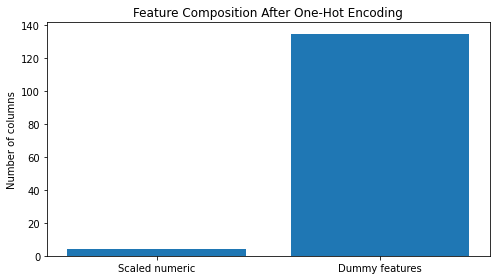

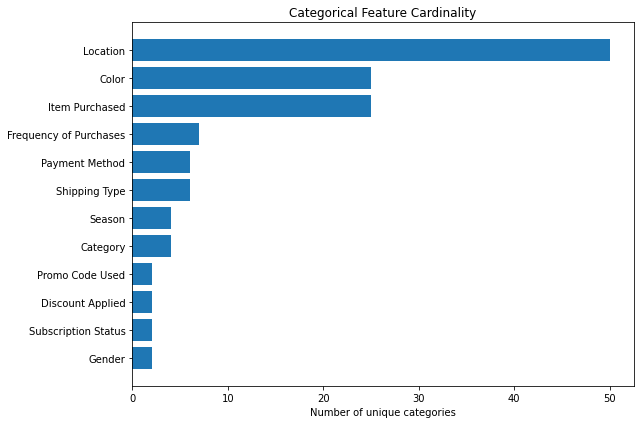

WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block05_categorical_cardinality.csv')

In [6]:
from sklearn.preprocessing import StandardScaler

df_onehot_source = df_selected.copy(
    deep=True
)

numeric_columns = (
    df_onehot_source
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

boolean_columns = (
    df_onehot_source
    .select_dtypes(
        include=["bool"]
    )
    .columns
    .tolist()
)

numeric_columns = [
    column
    for column in numeric_columns
    if column not in boolean_columns
]

categorical_columns = [
    column
    for column in df_onehot_source.columns
    if column not in numeric_columns
]

df_onehot_work = df_onehot_source.copy(
    deep=True
)

categorical_cardinality = {}

for column in categorical_columns:
    series = (
        df_onehot_work[column]
        .astype("string")
        .str.strip()
        .fillna("MISSING")
    )

    df_onehot_work[column] = series

    categorical_cardinality[column] = int(
        series.nunique(
            dropna=False
        )
    )

onehot_numeric_scaler = StandardScaler()

if numeric_columns:
    for column in numeric_columns:
        df_onehot_work[column] = pd.to_numeric(
            df_onehot_work[column],
            errors="coerce",
        )

    if (
        df_onehot_work[numeric_columns]
        .isna()
        .any()
        .any()
    ):
        medians = (
            df_onehot_work[numeric_columns]
            .median(numeric_only=True)
        )

        df_onehot_work[numeric_columns] = (
            df_onehot_work[numeric_columns]
            .fillna(medians)
        )

    df_onehot_work[numeric_columns] = (
        onehot_numeric_scaler.fit_transform(
            df_onehot_work[numeric_columns]
        )
    )

if categorical_columns:
    dummy_df = pd.get_dummies(
        df_onehot_work[
            categorical_columns
        ],
        prefix=categorical_columns,
        prefix_sep="_",
        drop_first=False,
        dtype=np.int8,
    )

    dummy_df = dummy_df.reindex(
        sorted(dummy_df.columns),
        axis=1,
    )
else:
    dummy_df = pd.DataFrame(
        index=df_onehot_work.index
    )

X_preprocessed = pd.concat(
    [
        df_onehot_work[
            numeric_columns
        ],
        dummy_df,
    ],
    axis=1,
)

X_preprocessed = (
    X_preprocessed
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

number_of_nan = int(
    X_preprocessed
    .isna()
    .sum()
    .sum()
)

number_of_inf = int(
    np.isinf(
        X_preprocessed
        .to_numpy(dtype=float)
    ).sum()
)

if (
    number_of_nan > 0
    or number_of_inf > 0
):
    raise ValueError(
        "Invalid values found in the expanded matrix: "
        f"NaN={number_of_nan}, Inf={number_of_inf}"
    )

encoding_summary_df = pd.DataFrame({
    "Representation": [
        "Scaled numeric columns",
        "Dummy columns",
        "Total expanded features",
    ],
    "Count": [
        len(numeric_columns),
        int(dummy_df.shape[1]),
        int(X_preprocessed.shape[1]),
    ],
})

cardinality_df = (
    pd.DataFrame({
        "Feature": list(
            categorical_cardinality.keys()
        ),
        "Unique_Categories": list(
            categorical_cardinality.values()
        ),
    })
    .sort_values(
        "Unique_Categories",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "One-hot/scaling diagnostic representation"
)
display(encoding_summary_df)

print("\nCategorical cardinality")
display(cardinality_df)

plt.figure(figsize=(7, 4))

plt.bar(
    [
        "Scaled numeric",
        "Dummy features",
    ],
    [
        len(numeric_columns),
        dummy_df.shape[1],
    ],
)

plt.ylabel("Number of columns")
plt.title(
    "Feature Composition After One-Hot Encoding"
)

finalize_figure(
    "block05_feature_composition.png"
)

if not cardinality_df.empty:
    ordered_cardinality = (
        cardinality_df
        .sort_values(
            "Unique_Categories"
        )
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        ordered_cardinality[
            "Feature"
        ],
        ordered_cardinality[
            "Unique_Categories"
        ],
    )

    plt.xlabel(
        "Number of unique categories"
    )
    plt.title(
        "Categorical Feature Cardinality"
    )

    finalize_figure(
        "block05_categorical_cardinality.png"
    )

save_dataframe(
    pd.DataFrame({
        "Feature_Name": X_preprocessed.columns
    }),
    "block05_expanded_feature_names.csv",
)

save_dataframe(
    encoding_summary_df,
    "block05_encoding_summary.csv",
)

save_dataframe(
    cardinality_df,
    "block05_categorical_cardinality.csv",
)

## Block 6 — True FAMD on mixed data

The clustering representation is created with true Factor Analysis of Mixed Data (FAMD).

The cleaned implementation preserves the supplied baseline logic:

1. numerical variables are converted to numeric and median-imputed only if needed;
2. numerical variables are standardized;
3. categorical variables remain categorical;
4. FAMD is fitted with additional components for reporting;
5. only the first three FAMD components are used in the baseline clustering stage.

The variance/inertia report uses Prince's own reported values where available.

In [7]:
from sklearn.preprocessing import StandardScaler

try:
    from prince import FAMD
except ImportError as exc:
    raise ImportError(
        "The 'prince' package is required for FAMD.\n"
        "Install the project requirements before continuing."
    ) from exc

df_famd = df_selected.copy(
    deep=True
)

famd_numeric_columns = (
    df_famd
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

famd_categorical_columns = [
    column
    for column in df_famd.columns
    if column not in famd_numeric_columns
]

famd_numeric_scaler = StandardScaler()

if famd_numeric_columns:
    for column in famd_numeric_columns:
        df_famd[column] = pd.to_numeric(
            df_famd[column],
            errors="coerce",
        )

    if (
        df_famd[famd_numeric_columns]
        .isna()
        .any()
        .any()
    ):
        medians = (
            df_famd[
                famd_numeric_columns
            ]
            .median(
                numeric_only=True
            )
        )

        df_famd[
            famd_numeric_columns
        ] = (
            df_famd[
                famd_numeric_columns
            ]
            .fillna(medians)
        )

    # Retained for fidelity with the supplied baseline implementation.
    df_famd[
        famd_numeric_columns
    ] = (
        famd_numeric_scaler
        .fit_transform(
            df_famd[
                famd_numeric_columns
            ]
        )
    )

for column in famd_categorical_columns:
    df_famd[column] = (
        df_famd[column]
        .astype("string")
        .str.strip()
        .fillna("MISSING")
        .astype("category")
    )

n_famd_report_components = int(
    min(
        MAX_FAMD_REPORT_COMPONENTS,
        max(
            N_COMPONENTS_FAMD,
            df_famd.shape[1],
        ),
    )
)

famd_model = FAMD(
    n_components=n_famd_report_components,
    random_state=RANDOM_STATE,
)

X_famd_full = (
    famd_model
    .fit_transform(df_famd)
)

if (
    X_famd_full.shape[1]
    < N_COMPONENTS_FAMD
):
    raise ValueError(
        "FAMD returned fewer components than required. "
        f"Returned={X_famd_full.shape[1]}, "
        f"required={N_COMPONENTS_FAMD}"
    )

X_red_np = (
    X_famd_full
    .iloc[
        :,
        :N_COMPONENTS_FAMD,
    ]
    .to_numpy(dtype=float)
)

component_names = [
    f"Comp{i}"
    for i in range(
        1,
        N_COMPONENTS_FAMD + 1,
    )
]

comp_df = pd.DataFrame(
    X_red_np,
    columns=component_names,
    index=df_selected.index,
)

(
    famd_variance_full_df,
    famd_variance_source,
    famd_variance_interpretation,
) = extract_famd_variance(
    famd_model
)

famd_variance_first3_df = (
    famd_variance_full_df
    .head(N_COMPONENTS_FAMD)
    .copy()
)

print("FAMD completed")
print("=" * 70)
print(
    "Mixed-data input shape:",
    df_famd.shape,
)
print(
    "FAMD transformed shape:",
    X_famd_full.shape,
)
print(
    "Clustering representation shape:",
    X_red_np.shape,
)
print(
    "Variance/inertia source:",
    famd_variance_source,
)
print(
    "Variance/inertia interpretation:",
    famd_variance_interpretation,
)

print(
    "\nFirst three FAMD components"
)
display(
    famd_variance_first3_df
)

save_dataframe(
    famd_variance_full_df,
    "block06_famd_variance_full.csv",
)

save_dataframe(
    famd_variance_first3_df,
    "block06_famd_variance_first3.csv",
)

save_dataframe(
    comp_df.reset_index(
        drop=True
    ),
    "block06_famd_components_3d.csv",
)

save_json(
    {
        "input_rows": int(
            df_famd.shape[0]
        ),
        "input_mixed_columns": int(
            df_famd.shape[1]
        ),
        "fitted_components": int(
            X_famd_full.shape[1]
        ),
        "clustering_components": int(
            N_COMPONENTS_FAMD
        ),
        "variance_source": famd_variance_source,
        "variance_interpretation": (
            famd_variance_interpretation
        ),
    },
    "block06_famd_metadata.json",
)

FAMD completed
Mixed-data input shape: (3900, 16)
FAMD transformed shape: (3900, 16)
Clustering representation shape: (3900, 3)
Variance/inertia source: percentage_of_variance_
Variance/inertia interpretation: Prince percentage-of-variance values

First three FAMD components


,Component_Number,Component,Prince_Raw_Value,Reported_Explained_Percent,Reported_Cumulative_Percent
0,1,Comp1,2.490248,2.490248,2.490248
1,2,Comp2,1.641312,1.641312,4.131560
2,3,Comp3,1.623720,1.623720,5.755280


WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block06_famd_metadata.json')

## Block 7 — Baseline clustering

The supplied baseline article implementation compares:

- KMeans
- Agglomerative Clustering with Ward linkage

for the candidate values `k = 3` and `k = 4`.

A KMeans sweep from 2 to 10 is additionally calculated for the elbow and silhouette diagnostics.

In [8]:
from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans,
)
from sklearn.metrics import silhouette_score

X = np.asarray(
    X_red_np,
    dtype=float,
)

if (
    X.ndim != 2
    or X.shape[1] != N_COMPONENTS_FAMD
):
    raise ValueError(
        "Unexpected reduced matrix shape. "
        f"Expected (n, {N_COMPONENTS_FAMD}); "
        f"received {X.shape}"
    )

labels: dict[str, np.ndarray] = {}
models: dict[str, Any] = {}

elbow_rows = []

for k in ELBOW_K_RANGE:
    model = KMeans(
        n_clusters=int(k),
        random_state=RANDOM_STATE,
        n_init=10,
    )

    predicted_labels = (
        model.fit_predict(X)
    )

    elbow_rows.append({
        "k": int(k),
        "Inertia": float(
            model.inertia_
        ),
        "Silhouette": float(
            silhouette_score(
                X,
                predicted_labels,
            )
        ),
    })

    models[
        f"kmeans_k{k}"
    ] = model

    if k in K_CANDIDATES:
        labels[
            f"kmeans_k{k}"
        ] = predicted_labels

for k in K_CANDIDATES:
    model = AgglomerativeClustering(
        n_clusters=int(k),
        linkage="ward",
    )

    labels[
        f"agglo_ward_k{k}"
    ] = model.fit_predict(X)

kmeans_diagnostic_df = pd.DataFrame(
    elbow_rows
)

cluster_size_rows = []

for method_name, method_labels in labels.items():
    unique_labels, counts = np.unique(
        method_labels,
        return_counts=True,
    )

    cluster_size_rows.append({
        "Method": method_name,
        "Number_of_Clusters": int(
            len(unique_labels)
        ),
        "Cluster_Sizes": str(
            dict(
                zip(
                    unique_labels
                    .astype(int)
                    .tolist(),
                    counts
                    .astype(int)
                    .tolist(),
                )
            )
        ),
    })

cluster_sizes_df = pd.DataFrame(
    cluster_size_rows
)

print("KMeans diagnostic sweep")
display(kmeans_diagnostic_df)

print(
    "\nCandidate clustering sizes"
)
display(cluster_sizes_df)

save_dataframe(
    kmeans_diagnostic_df,
    "block07_kmeans_diagnostics.csv",
)

save_dataframe(
    cluster_sizes_df,
    "block07_cluster_sizes.csv",
)

save_dataframe(
    pd.DataFrame({
        name: np.asarray(
            values,
            dtype=int,
        )
        for name, values in labels.items()
    }),
    "block07_candidate_labels.csv",
)

KMeans diagnostic sweep


,k,Inertia,Silhouette
0,2,100799.791628,0.430180
1,3,73617.553578,0.491070
2,4,44345.972428,0.564877
3,5,33092.962239,0.573246
4,6,22544.391969,0.620926
5,7,14065.275383,0.656794
6,8,8533.476667,0.682450
7,9,7310.782312,0.641280
8,10,6158.329959,0.628413



Candidate clustering sizes


,Method,Number_of_Clusters,Cluster_Sizes
0,kmeans_k3,3,"{0: 599, 1: 1883, 2: 1418}"
1,kmeans_k4,4,"{0: 599, 1: 1703, 2: 1274, 3: 324}"
2,agglo_ward_k3,3,"{0: 923, 1: 1703, 2: 1274}"
3,agglo_ward_k4,4,"{0: 1703, 1: 599, 2: 1274, 3: 324}"


WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block07_candidate_labels.csv')

## Block 8 — Internal clustering evaluation

The candidate partitions are evaluated with:

- Silhouette Score — higher is better;
- Davies-Bouldin Index (DBI) — lower is better;
- Calinski-Harabasz Index (CHI) — higher is better.

Compact Table-3-style and Table-6-style outputs are also exported.

All baseline clustering metrics


,Key,Model,k,n_clusters,Silhouette,DBI,CHI
0,agglo_ward_k3,Agglomerative(Ward),3,3,0.485864,1.073681,2639.604696
1,agglo_ward_k4,Agglomerative(Ward),4,4,0.564877,0.737173,3596.445351
2,kmeans_k3,KMeans,3,3,0.491070,0.891033,2475.734648
3,kmeans_k4,KMeans,4,4,0.564877,0.737173,3596.445351



Table-3-style silhouette report


k,Model,Sil_k3,Sil_k4
0,Agglomerative(Ward),0.485864,0.564877
1,KMeans,0.491070,0.564877



Table-6-style k=4 report


,Model,DBI,CHI
0,Agglomerative(Ward),0.737173,3596.445351
1,KMeans,0.737173,3596.445351



Best candidate by each metric


,Criterion,Model,k,Score
0,Best Silhouette,Agglomerative(Ward),4,0.564877
1,Best DBI,Agglomerative(Ward),4,0.737173
2,Best CHI,Agglomerative(Ward),4,3596.445351


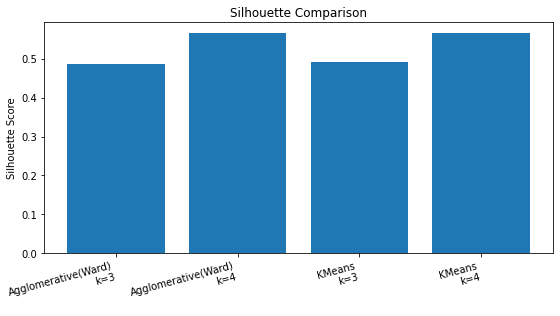

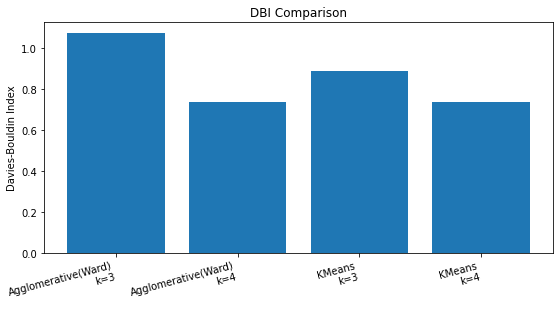

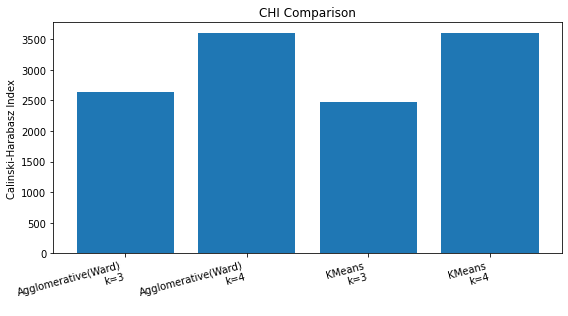

WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block08_best_models.csv')

In [9]:
def parse_method_key(
    key: str,
) -> tuple[str, int | None]:
    """Convert an internal label key into a readable model name and k."""
    text = str(key).lower()

    if text.startswith("kmeans"):
        model_name = "KMeans"

    elif (
        text.startswith("agglo")
        or "ward" in text
    ):
        model_name = (
            "Agglomerative(Ward)"
        )

    else:
        model_name = "Other"

    k_value = None

    if "_k" in text:
        try:
            k_value = int(
                text.rsplit(
                    "_k",
                    1,
                )[1]
            )
        except ValueError:
            k_value = None

    return model_name, k_value


metric_rows = []

for key, predicted_labels in labels.items():
    (
        model_name,
        k_value,
    ) = parse_method_key(key)

    if k_value not in K_CANDIDATES:
        continue

    metrics = cluster_metrics(
        X,
        predicted_labels,
    )

    metric_rows.append({
        "Key": key,
        "Model": model_name,
        "k": int(k_value),
        "n_clusters": int(
            len(
                np.unique(
                    predicted_labels
                )
            )
        ),
        **metrics,
    })

results_df = (
    pd.DataFrame(metric_rows)
    .sort_values(
        [
            "Model",
            "k",
        ]
    )
    .reset_index(
        drop=True
    )
)

if results_df.empty:
    raise ValueError(
        "No clustering-evaluation results were produced."
    )

table3_df = (
    results_df
    .pivot_table(
        index="Model",
        columns="k",
        values="Silhouette",
        aggfunc="first",
    )
    .reset_index()
)

for candidate_k in [3, 4]:
    if candidate_k not in table3_df.columns:
        table3_df[
            candidate_k
        ] = np.nan

table3_df = (
    table3_df[
        [
            "Model",
            3,
            4,
        ]
    ]
    .rename(
        columns={
            3: "Sil_k3",
            4: "Sil_k4",
        }
    )
)

table6_df = (
    results_df
    .loc[
        results_df["k"] == 4,
        [
            "Model",
            "DBI",
            "CHI",
        ],
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

best_silhouette_row = (
    results_df
    .loc[
        results_df[
            "Silhouette"
        ].idxmax()
    ]
)

best_dbi_row = (
    results_df
    .loc[
        results_df[
            "DBI"
        ].idxmin()
    ]
)

best_chi_row = (
    results_df
    .loc[
        results_df[
            "CHI"
        ].idxmax()
    ]
)

best_models_df = pd.DataFrame([
    {
        "Criterion": "Best Silhouette",
        "Model": best_silhouette_row[
            "Model"
        ],
        "k": int(
            best_silhouette_row["k"]
        ),
        "Score": float(
            best_silhouette_row[
                "Silhouette"
            ]
        ),
    },
    {
        "Criterion": "Best DBI",
        "Model": best_dbi_row[
            "Model"
        ],
        "k": int(
            best_dbi_row["k"]
        ),
        "Score": float(
            best_dbi_row["DBI"]
        ),
    },
    {
        "Criterion": "Best CHI",
        "Model": best_chi_row[
            "Model"
        ],
        "k": int(
            best_chi_row["k"]
        ),
        "Score": float(
            best_chi_row["CHI"]
        ),
    },
])

print(
    "All baseline clustering metrics"
)
display(results_df)

print(
    "\nTable-3-style silhouette report"
)
display(table3_df)

print(
    "\nTable-6-style k=4 report"
)
display(table6_df)

print(
    "\nBest candidate by each metric"
)
display(best_models_df)

for metric, y_label in [
    (
        "Silhouette",
        "Silhouette Score",
    ),
    (
        "DBI",
        "Davies-Bouldin Index",
    ),
    (
        "CHI",
        "Calinski-Harabasz Index",
    ),
]:
    plt.figure(
        figsize=(8, 4.5)
    )

    x_positions = np.arange(
        len(results_df)
    )

    plt.bar(
        x_positions,
        results_df[
            metric
        ].to_numpy(
            dtype=float
        ),
    )

    plt.xticks(
        x_positions,
        [
            (
                f"{row.Model}\n"
                f"k={int(row.k)}"
            )
            for row
            in results_df.itertuples()
        ],
        rotation=15,
        ha="right",
    )

    plt.ylabel(y_label)

    plt.title(
        f"{metric} Comparison"
    )

    finalize_figure(
        f"block08_{metric.lower()}_comparison.png"
    )

save_dataframe(
    results_df,
    "block08_all_metrics.csv",
)

save_dataframe(
    table3_df,
    "block08_table3_silhouette.csv",
)

save_dataframe(
    table6_df,
    "block08_table6_dbi_chi_k4.csv",
)

save_dataframe(
    best_models_df,
    "block08_best_models.csv",
)

## Block 9 — Elbow, silhouette, and dendrogram diagnostics

These figures provide visual support for cluster-number selection.

The final interpretation should be based on the quantitative metrics together with the candidate values used in the baseline paper.

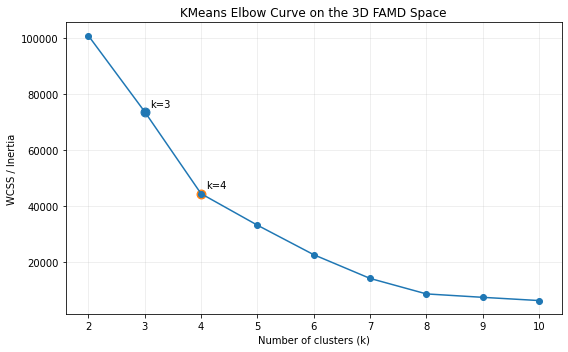

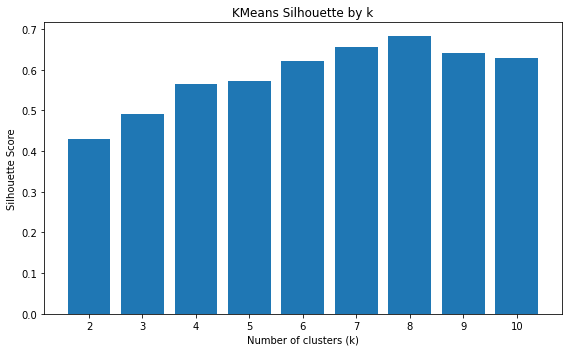

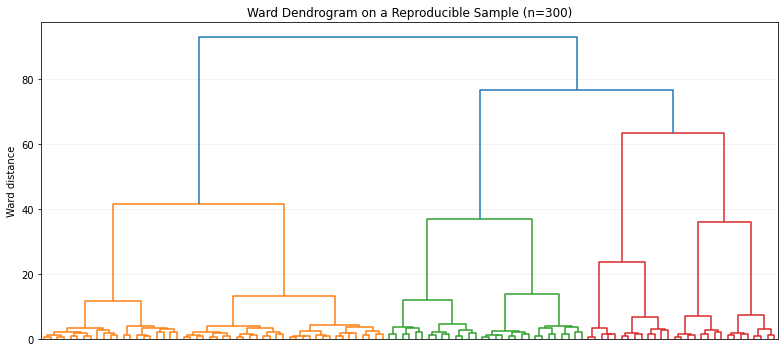

In [10]:
# -------------------------------------------------------------
# KMeans elbow curve
# -------------------------------------------------------------
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    kmeans_diagnostic_df["k"],
    kmeans_diagnostic_df[
        "Inertia"
    ],
    marker="o",
)

for candidate_k in K_CANDIDATES:
    matching_row = (
        kmeans_diagnostic_df
        .loc[
            kmeans_diagnostic_df[
                "k"
            ] == candidate_k
        ]
    )

    if not matching_row.empty:
        x_value = int(
            matching_row[
                "k"
            ].iloc[0]
        )

        y_value = float(
            matching_row[
                "Inertia"
            ].iloc[0]
        )

        plt.scatter(
            x_value,
            y_value,
            s=80,
        )

        plt.annotate(
            f"k={candidate_k}",
            (
                x_value,
                y_value,
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

plt.xlabel(
    "Number of clusters (k)"
)
plt.ylabel(
    "WCSS / Inertia"
)
plt.title(
    "KMeans Elbow Curve on the 3D FAMD Space"
)
plt.grid(
    alpha=0.25
)

finalize_figure(
    "block09_kmeans_elbow.png"
)

# -------------------------------------------------------------
# KMeans silhouette diagnostic
# -------------------------------------------------------------
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    kmeans_diagnostic_df[
        "k"
    ].astype(str),
    kmeans_diagnostic_df[
        "Silhouette"
    ],
)

plt.xlabel(
    "Number of clusters (k)"
)
plt.ylabel(
    "Silhouette Score"
)
plt.title(
    "KMeans Silhouette by k"
)

finalize_figure(
    "block09_kmeans_silhouette.png"
)

# -------------------------------------------------------------
# Reproducibly sampled Ward dendrogram
# -------------------------------------------------------------
try:
    from scipy.cluster.hierarchy import (
        dendrogram,
        linkage,
    )

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    dendrogram_sample_size = min(
        300,
        len(X),
    )

    sample_indices = rng.choice(
        len(X),
        size=dendrogram_sample_size,
        replace=False,
    )

    X_dendrogram = X[
        sample_indices
    ]

    ward_linkage = linkage(
        X_dendrogram,
        method="ward",
    )

    plt.figure(
        figsize=(11, 5)
    )

    dendrogram(
        ward_linkage,
        truncate_mode="level",
        p=6,
        no_labels=True,
    )

    plt.ylabel(
        "Ward distance"
    )

    plt.title(
        "Ward Dendrogram on a Reproducible Sample "
        f"(n={dendrogram_sample_size})"
    )

    plt.grid(
        axis="y",
        alpha=0.2,
    )

    finalize_figure(
        "block09_ward_dendrogram_sampled.png"
    )

except ImportError:
    print(
        "SciPy is unavailable; "
        "the dendrogram was skipped."
    )

## Block 10 — Cluster visualizations and profiling

The default profile is `agglo_ward_k4`, matching the supplied baseline implementation.

The profiling table uses the modelling-scale customer variables after the baseline capping step.
Numerical features are summarized by cluster means, and categorical features by mode and mode share.

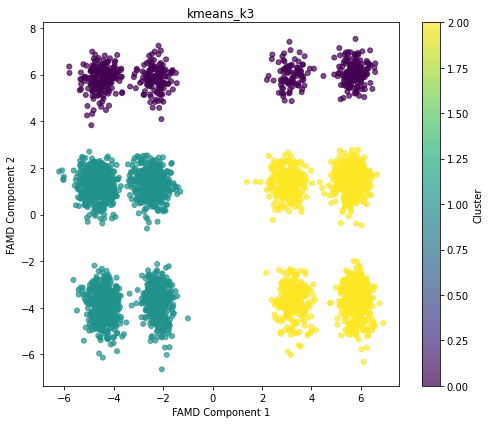

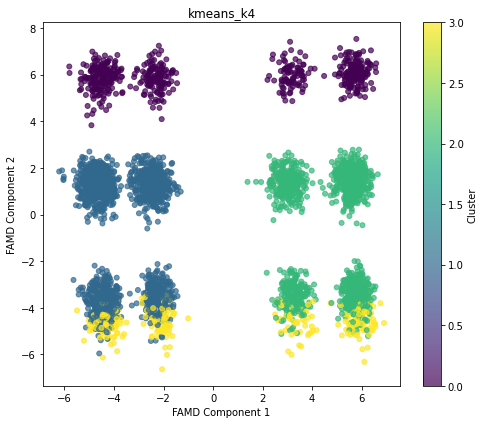

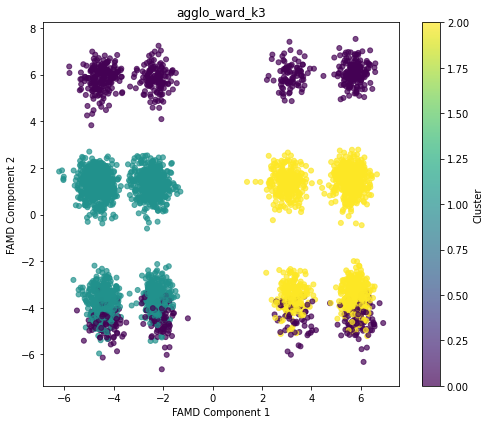

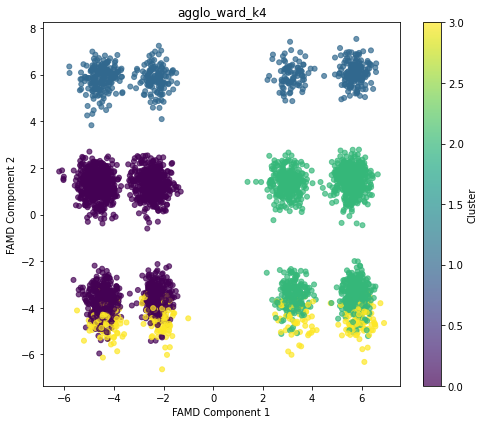

Profile partition: agglo_ward_k4

Cluster sizes


,Cluster,Size
0,0,1703
1,1,599
2,2,1274
3,3,324



Numerical cluster means


,Cluster,Age,Purchase Amount (USD),Review Rating,Previous Purchases
0,0,43.910159,60.454756,3.750029,25.237228
1,1,44.442404,60.206511,3.790651,25.262104
2,2,44.042386,59.184301,3.731476,25.659341
3,3,44.311728,57.113580,3.746914,24.987654



Categorical modes and mode shares


,Cluster,Gender__Mode,Gender__Mode_Share_Percent,Item Purchased__Mode,Item Purchased__Mode_Share_Percent,Category__Mode,Category__Mode_Share_Percent,Location__Mode,Location__Mode_Share_Percent,Color__Mode,...,Shipping Type__Mode,Shipping Type__Mode_Share_Percent,Discount Applied__Mode,Discount Applied__Mode_Share_Percent,Promo Code Used__Mode,Promo Code Used__Mode_Share_Percent,Payment Method__Mode,Payment Method__Mode_Share_Percent,Frequency of Purchases__Mode,Frequency of Purchases__Mode_Share_Percent
0,0,Female,55.666471,Blouse,6.635349,Clothing,59.072225,Montana,2.818555,Green,...,Free Shipping,17.322372,No,100.000000,No,100.000000,PayPal,17.733412,Annually,15.267176
1,1,Male,66.777963,Sandals,26.711185,Footwear,100.000000,Ohio,3.005008,Olive,...,Free Shipping,20.367279,No,56.761269,No,56.761269,Venmo,18.030050,Fortnightly,16.026711
2,2,Male,100.000000,Pants,6.357928,Clothing,57.378336,Indiana,2.904239,Charcoal,...,Standard,17.346939,Yes,100.000000,Yes,100.000000,Credit Card,17.660911,Every 3 Months,15.463108
3,3,Male,68.827160,Jacket,50.308642,Outerwear,100.000000,North Dakota,4.320988,Blue,...,Free Shipping,19.753086,No,55.555556,No,55.555556,PayPal,18.518519,Fortnightly,16.358025


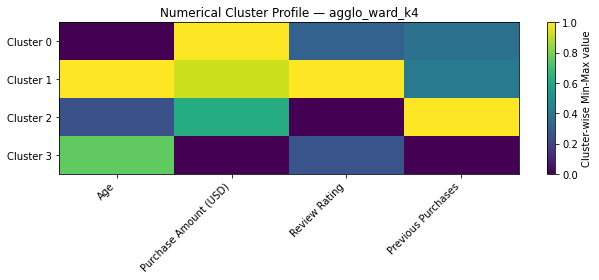

WindowsPath('C:/Users/Sina/Desktop/دفاع/GITHUB/THE IMPLEMENTATION OF BASELINE ARTICLE/outputs/baseline_replication/20260921_143943/block10_profile_categorical_modes.csv')

In [11]:
if PROFILE_LABEL_KEY not in labels:
    raise KeyError(
        f"{PROFILE_LABEL_KEY!r} is not available. "
        f"Available label sets: {list(labels.keys())}"
    )

# -------------------------------------------------------------
# Candidate scatter plots in the first two FAMD dimensions
# -------------------------------------------------------------
for (
    method_name,
    predicted_labels,
) in labels.items():

    plt.figure(
        figsize=(7, 6)
    )

    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=predicted_labels,
        s=25,
        alpha=0.70,
    )

    plt.xlabel(
        "FAMD Component 1"
    )
    plt.ylabel(
        "FAMD Component 2"
    )
    plt.title(
        method_name
    )

    plt.colorbar(
        scatter,
        label="Cluster",
    )

    finalize_figure(
        f"block10_{method_name}_scatter.png"
    )

# -------------------------------------------------------------
# Interpretable customer-segment profiling
# -------------------------------------------------------------
profile_labels = np.asarray(
    labels[
        PROFILE_LABEL_KEY
    ]
)

df_profile = df_selected.copy(
    deep=True
)

if len(df_profile) != len(
    profile_labels
):
    raise ValueError(
        "Row-count mismatch between the modelling table "
        "and the selected cluster labels."
    )

unique_profile_labels = sorted(
    np.unique(
        profile_labels
    ).tolist()
)

label_map = {
    original_label: new_label
    for (
        new_label,
        original_label,
    ) in enumerate(
        unique_profile_labels
    )
}

df_profile["Cluster"] = [
    label_map[label]
    for label in profile_labels
]

profile_numeric_columns = (
    df_profile
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

profile_numeric_columns = [
    column
    for column in profile_numeric_columns
    if column != "Cluster"
]

profile_categorical_columns = [
    column
    for column in df_profile.columns
    if (
        column
        not in (
            profile_numeric_columns
            + ["Cluster"]
        )
    )
]

cluster_profile_sizes_df = (
    df_profile
    .groupby("Cluster")
    .size()
    .reset_index(
        name="Size"
    )
)

numeric_profile_raw_df = (
    df_profile
    .groupby("Cluster")[
        profile_numeric_columns
    ]
    .mean(
        numeric_only=True
    )
    .reset_index()
)

numeric_profile_minmax_df = (
    numeric_profile_raw_df
    .copy()
)

for column in profile_numeric_columns:
    values = (
        numeric_profile_minmax_df[
            column
        ]
        .astype(float)
    )

    minimum = float(
        values.min()
    )
    maximum = float(
        values.max()
    )

    if abs(
        maximum - minimum
    ) < 1e-12:
        numeric_profile_minmax_df[
            column
        ] = 0.0
    else:
        numeric_profile_minmax_df[
            column
        ] = (
            (values - minimum)
            / (maximum - minimum)
        )

categorical_profile_rows = []

for (
    cluster_id,
    cluster_group,
) in df_profile.groupby(
    "Cluster"
):
    row = {
        "Cluster": int(
            cluster_id
        )
    }

    for column in profile_categorical_columns:
        series = (
            cluster_group[
                column
            ]
            .astype("string")
            .fillna("Missing")
        )

        mode_value = (
            series
            .mode()
            .iloc[0]
        )

        mode_share_percent = float(
            (
                series
                == mode_value
            )
            .mean()
            * 100.0
        )

        row[
            f"{column}__Mode"
        ] = mode_value

        row[
            f"{column}__Mode_Share_Percent"
        ] = mode_share_percent

    categorical_profile_rows.append(
        row
    )

categorical_profile_df = pd.DataFrame(
    categorical_profile_rows
)

print(
    "Profile partition:",
    PROFILE_LABEL_KEY,
)

print(
    "\nCluster sizes"
)
display(
    cluster_profile_sizes_df
)

print(
    "\nNumerical cluster means"
)
display(
    numeric_profile_raw_df
)

print(
    "\nCategorical modes and mode shares"
)
display(
    categorical_profile_df
)

if profile_numeric_columns:
    heatmap_data = (
        numeric_profile_minmax_df
        .set_index(
            "Cluster"
        )[
            profile_numeric_columns
        ]
    )

    plt.figure(
        figsize=(
            max(
                9,
                0.9
                * len(
                    profile_numeric_columns
                ),
            ),
            max(
                4,
                0.7
                * len(
                    heatmap_data
                ),
            ),
        )
    )

    image = plt.imshow(
        heatmap_data.to_numpy(
            dtype=float
        ),
        aspect="auto",
    )

    plt.colorbar(
        image,
        label=(
            "Cluster-wise Min-Max value"
        ),
    )

    plt.yticks(
        range(
            len(
                heatmap_data
            )
        ),
        [
            f"Cluster {index}"
            for index
            in heatmap_data.index
        ],
    )

    plt.xticks(
        range(
            len(
                profile_numeric_columns
            )
        ),
        profile_numeric_columns,
        rotation=45,
        ha="right",
    )

    plt.title(
        "Numerical Cluster Profile — "
        f"{PROFILE_LABEL_KEY}"
    )

    finalize_figure(
        "block10_numeric_profile_heatmap.png"
    )

save_dataframe(
    cluster_profile_sizes_df,
    "block10_profile_cluster_sizes.csv",
)

save_dataframe(
    numeric_profile_raw_df,
    "block10_profile_numeric_means.csv",
)

save_dataframe(
    numeric_profile_minmax_df,
    "block10_profile_numeric_minmax.csv",
)

save_dataframe(
    categorical_profile_df,
    "block10_profile_categorical_modes.csv",
)

## Block 11 — FAMD dimensionality sensitivity analysis

This supplementary block evaluates whether using more FAMD components changes clustering quality.

It does **not** replace or overwrite the main three-component baseline analysis.

The already-fitted FAMD coordinates from Block 6 are reused, avoiding an unnecessary second FAMD fit.

FAMD cumulative variance/inertia summary


,n_components,Reported_Cumulative_Percent,Variance_Interpretation
0,3,5.755280,Prince percentage-of-variance values
1,5,8.356334,Prince percentage-of-variance values
2,8,11.230189,Prince percentage-of-variance values
3,10,13.095017,Prince percentage-of-variance values
4,12,14.921537,Prince percentage-of-variance values
5,15,17.613422,Prince percentage-of-variance values
6,16,18.498869,Prince percentage-of-variance values



Clustering sensitivity to FAMD dimensionality


,n_components,Algorithm,k,Silhouette,DBI,CHI
0,3,KMeans,3,0.491070,0.891033,2475.734648
1,3,Agglomerative(Ward),3,0.485864,1.073681,2639.604696
2,3,KMeans,4,0.564877,0.737173,3596.445351
3,3,Agglomerative(Ward),4,0.564877,0.737173,3596.445351
4,5,KMeans,3,0.351235,1.192047,1525.691694
5,5,Agglomerative(Ward),3,0.342090,1.387352,1282.745306
6,5,KMeans,4,0.409783,1.018546,1839.806332
7,5,Agglomerative(Ward),4,0.409783,1.018546,1839.806332
8,8,KMeans,3,0.243717,1.539486,944.847796
9,8,Agglomerative(Ward),3,0.228882,1.769732,815.912843


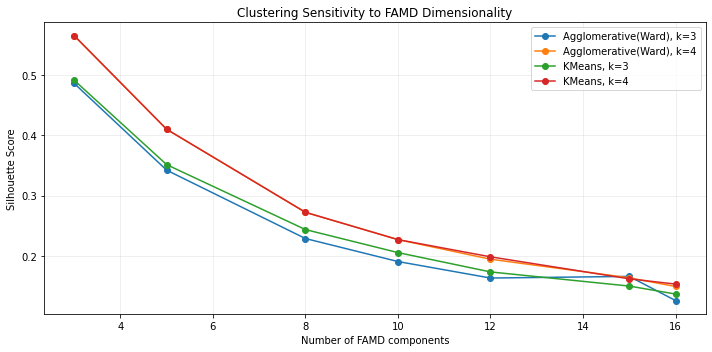

In [12]:
from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans,
)

if RUN_FAMD_SENSITIVITY:
    n_available_components = int(
        X_famd_full.shape[1]
    )

    tested_component_counts = sorted({
        int(number)
        for number in (
            SENSITIVITY_COMPONENTS
            + [
                N_COMPONENTS_FAMD,
                n_available_components,
            ]
        )
        if (
            int(number) >= 1
            and int(number)
            <= n_available_components
        )
    })

    variance_summary_rows = []

    for number_of_components in tested_component_counts:
        if (
            number_of_components
            <= len(
                famd_variance_full_df
            )
        ):
            row = (
                famd_variance_full_df
                .iloc[
                    number_of_components
                    - 1
                ]
            )

            variance_summary_rows.append({
                "n_components": (
                    number_of_components
                ),
                "Reported_Cumulative_Percent": float(
                    row[
                        "Reported_Cumulative_Percent"
                    ]
                ),
                "Variance_Interpretation": (
                    famd_variance_interpretation
                ),
            })

    famd_component_summary_df = (
        pd.DataFrame(
            variance_summary_rows
        )
    )

    sensitivity_rows = []

    for number_of_components in tested_component_counts:
        X_n = (
            X_famd_full
            .iloc[
                :,
                :number_of_components,
            ]
            .to_numpy(
                dtype=float
            )
        )

        for k in SENSITIVITY_K_VALUES:
            kmeans_model = KMeans(
                n_clusters=int(k),
                random_state=RANDOM_STATE,
                n_init=10,
            )

            kmeans_labels = (
                kmeans_model
                .fit_predict(X_n)
            )

            sensitivity_rows.append({
                "n_components": (
                    number_of_components
                ),
                "Algorithm": "KMeans",
                "k": int(k),
                **cluster_metrics(
                    X_n,
                    kmeans_labels,
                ),
            })

            agglo_model = (
                AgglomerativeClustering(
                    n_clusters=int(k),
                    linkage="ward",
                )
            )

            agglo_labels = (
                agglo_model
                .fit_predict(X_n)
            )

            sensitivity_rows.append({
                "n_components": (
                    number_of_components
                ),
                "Algorithm": (
                    "Agglomerative(Ward)"
                ),
                "k": int(k),
                **cluster_metrics(
                    X_n,
                    agglo_labels,
                ),
            })

    famd_clustering_sensitivity_df = (
        pd.DataFrame(
            sensitivity_rows
        )
    )

    print(
        "FAMD cumulative variance/inertia summary"
    )
    display(
        famd_component_summary_df
    )

    print(
        "\nClustering sensitivity to FAMD dimensionality"
    )
    display(
        famd_clustering_sensitivity_df
    )

    plt.figure(
        figsize=(10, 5)
    )

    for (
        algorithm,
        k,
    ), group in (
        famd_clustering_sensitivity_df
        .groupby(
            [
                "Algorithm",
                "k",
            ]
        )
    ):
        group = group.sort_values(
            "n_components"
        )

        plt.plot(
            group[
                "n_components"
            ],
            group[
                "Silhouette"
            ],
            marker="o",
            label=(
                f"{algorithm}, k={k}"
            ),
        )

    plt.xlabel(
        "Number of FAMD components"
    )
    plt.ylabel(
        "Silhouette Score"
    )
    plt.title(
        "Clustering Sensitivity to FAMD Dimensionality"
    )
    plt.legend()
    plt.grid(
        alpha=0.25
    )

    finalize_figure(
        "block11_famd_sensitivity_silhouette.png"
    )

    save_dataframe(
        famd_component_summary_df,
        "block11_famd_component_summary.csv",
    )

    save_dataframe(
        famd_clustering_sensitivity_df,
        "block11_famd_clustering_sensitivity.csv",
    )

else:
    print(
        "FAMD sensitivity analysis is disabled."
    )

## Block 12 — Final run summary and export manifest

The final block records the main shapes, settings, and generated files.
It does not alter any analytical result.

In [13]:
run_summary = {
    "run_id": RUN_ID,
    "dataset_path": str(
        DATASET_PATH
    ),
    "dataset_path_source": (
        DATASET_PATH_SOURCE
    ),
    "dataset_shape": [
        int(df.shape[0]),
        int(df.shape[1]),
    ],
    "model_table_shape": [
        int(
            df_selected.shape[0]
        ),
        int(
            df_selected.shape[1]
        ),
    ],
    "onehot_diagnostic_shape": [
        int(
            X_preprocessed.shape[0]
        ),
        int(
            X_preprocessed.shape[1]
        ),
    ],
    "famd_full_shape": [
        int(
            X_famd_full.shape[0]
        ),
        int(
            X_famd_full.shape[1]
        ),
    ],
    "famd_clustering_shape": [
        int(
            X_red_np.shape[0]
        ),
        int(
            X_red_np.shape[1]
        ),
    ],
    "k_candidates": K_CANDIDATES,
    "profile_partition": (
        PROFILE_LABEL_KEY
    ),
    "famd_variance_source": (
        famd_variance_source
    ),
    "famd_variance_interpretation": (
        famd_variance_interpretation
    ),
}

save_json(
    run_summary,
    "run_summary.json",
)

generated_files = sorted(
    path.name
    for path in OUT_DIR.iterdir()
    if path.is_file()
)

manifest_df = pd.DataFrame({
    "Generated_File": generated_files
})

print("Final run summary")
display(
    pd.DataFrame(
        run_summary.items(),
        columns=[
            "Item",
            "Value",
        ],
    )
)

print(
    "\nGenerated files"
)
display(manifest_df)

save_dataframe(
    manifest_df,
    "run_manifest.csv",
)

print(
    "\nBaseline article replication completed successfully."
)
print(
    "Outputs:",
    OUT_DIR.resolve(),
)

Final run summary


,Item,Value
0,run_id,20260921_143943
1,dataset_path,C:\Users\Sina\Desktop\Thesis\Shopping_Trends_A...
2,dataset_path_source,local thesis path
3,dataset_shape,"[3900, 17]"
4,model_table_shape,"[3900, 16]"
5,onehot_diagnostic_shape,"[3900, 139]"
6,famd_full_shape,"[3900, 16]"
7,famd_clustering_shape,"[3900, 3]"
8,k_candidates,"[3, 4]"
9,profile_partition,agglo_ward_k4



Generated files


,Generated_File
0,block02_sanity.json
1,block02_schema.csv
2,block03_percentile_capping.csv
3,block04_eta_metadata.json
4,block04_eta_report.csv
5,block05_categorical_cardinality.csv
6,block05_categorical_cardinality.png
7,block05_encoding_summary.csv
8,block05_expanded_feature_names.csv
9,block05_feature_composition.png



Baseline article replication completed successfully.
Outputs: C:\Users\Sina\Desktop\دفاع\GITHUB\THE IMPLEMENTATION OF BASELINE ARTICLE\outputs\baseline_replication\20260921_143943
